In [2]:
import numpy as np
from sklearn.manifold import TSNE
import json

In [3]:
embeddings = np.load("artifacts/cbramod_embeddings/embeddings.npy")
metadata = json.load(open("artifacts/cbramod_embeddings/metadata.json", "r"))

In [4]:
print(embeddings.shape)

(4, 19, 200)


In [11]:
labels = np.array([m["pathological"] for m in metadata])
labels = np.expand_dims(labels, axis=1)
labels = np.repeat(labels, embeddings.shape[1], axis=1)
print(labels.shape)
labels = labels.reshape(-1)
print(labels.shape)


(4, 19)
(76,)


In [12]:
embeddings = embeddings.reshape(-1, embeddings.shape[-1])
print(embeddings.shape)

(76, 200)


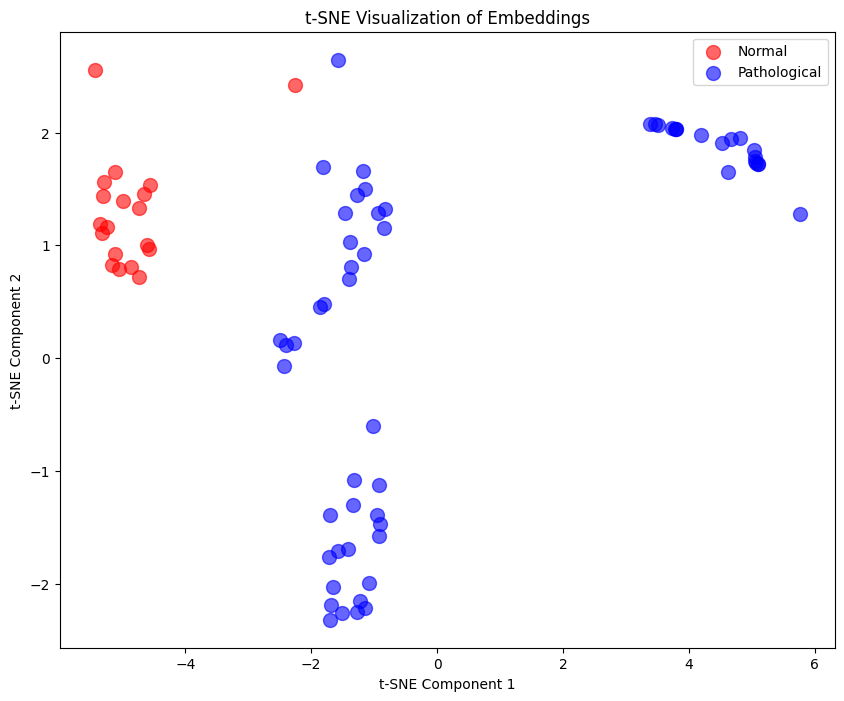

In [13]:
import matplotlib.pyplot as plt


# Apply t-SNE to reduce embeddings to 2D
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

normal_labels = np.array(labels)


# Create scatter plot with labels as colors
plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[labels == 0,0], embeddings_2d[labels == 0, 1], c='red', label='Normal', alpha=0.6, s=100)
plt.scatter(embeddings_2d[labels == 1, 0], embeddings_2d[labels == 1, 1], c='blue', label='Pathological', alpha=0.6, s=100)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE Visualization of Embeddings')
plt.legend()
plt.show()